## Libraries

In [21]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

Read and converting male & female into 1 and 0, divided Embarked into S and Q

In [3]:
# Đọc file
df = pd.read_csv('/content/cleaned_data.csv')

df['Sex'] = df['Sex'].map({'male': 1, 'female': 0})
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df_encoded = pd.get_dummies(df, columns=['Embarked'], drop_first=True, dtype=int)
df_encoded.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,FamilySize,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",1,22.000000,1,0,A/5 21171,7.2500,2,0,1
1,3,1,3,"Heikkinen, Miss. Laina",0,26.000000,0,0,STON/O2. 3101282,7.9250,1,0,1
2,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.000000,1,0,113803,53.1000,2,0,1
3,5,0,3,"Allen, Mr. William Henry",1,35.000000,0,0,373450,8.0500,1,0,1
4,6,0,3,"Moran, Mr. James",1,29.699118,0,0,330877,8.4583,1,1,0


What its looked like without encoded:

In [4]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize
0,1,0,3,"Braund, Mr. Owen Harris",1,22.000000,1,0,A/5 21171,7.2500,S,2
1,3,1,3,"Heikkinen, Miss. Laina",0,26.000000,0,0,STON/O2. 3101282,7.9250,S,1
2,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.000000,1,0,113803,53.1000,S,2
3,5,0,3,"Allen, Mr. William Henry",1,35.000000,0,0,373450,8.0500,S,1
4,6,0,3,"Moran, Mr. James",1,29.699118,0,0,330877,8.4583,Q,1


Kiểm tra cấu trúc dữ liệu ban đầu tên cột, kiểu dữ liệu, số lượng giá trị thiếu và tỷ lệ thiếu của từng cột. Đồng thời kiểm tra phân bố của target Survived để biết số mẫu sống sót và không sống sót.

In [42]:
print("Thông tin cột:")
display(pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "missing_percent": (df.isna().mean() * 100).round(2)
}))


Thông tin cột:


,column,dtype,missing,missing_percent
PassengerId,PassengerId,int64,0,0.0
Survived,Survived,int64,0,0.0
Pclass,Pclass,int64,0,0.0
Name,Name,object,0,0.0
Sex,Sex,int64,0,0.0
Age,Age,float64,0,0.0
SibSp,SibSp,int64,0,0.0
Parch,Parch,int64,0,0.0
Ticket,Ticket,object,0,0.0
Fare,Fare,float64,0,0.0


## Choose target

In this scenario, we will choose: 'Fare'
Relevant variables: Pclass, Sex, Age, Sibsp, Parch, Embarked, and Survived.

In [6]:
target_col = "Fare"

numeric_features = ["Pclass", "Age", "SibSp", "Parch", "Fare", "FamilySize"]
categorical_features = ["Sex", "Embarked"]

X = df[numeric_features + categorical_features].copy()
y = df[target_col].astype("float32").copy()

print("Input features:", list(X.columns))
print("Target:", target_col)
print("X shape:", X.shape)
print("y shape:", y.shape)


Input features: ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'Sex', 'Embarked']
Target: Fare
X shape: (775, 8)
y shape: (775,)


In [7]:
# Split the data (80% training, 20% validation)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training dataset size: {X_train.shape[0]} rows")
print(f"Testing dataset size:  {X_test.shape[0]} rows")

Training dataset size: 620 rows
Testing dataset size:  155 rows


## Load Linear Regression model

In [10]:
model = LinearRegression()

# Preprocess X_train before fitting:
# 1. Remove the 'Fare' column, as it is the target variable.
# 2. One-hot encode the 'Embarked' column, which currently contains string values.
X_train_processed = X_train.drop(columns=['Fare']).copy()
X_train_processed = pd.get_dummies(X_train_processed, columns=['Embarked'], drop_first=True, dtype=int)

# Train the model weights using the preprocessed training split
model.fit(X_train_processed, y_train)

print("Linear Regression Model training complete!")

Linear Regression Model training complete!


In [12]:
# Make predictions on the test set
# Apply the same preprocessing to X_test as was applied to X_train
X_test_processed = X_test.drop(columns=['Fare']).copy()
X_test_processed = pd.get_dummies(X_test_processed, columns=['Embarked'], drop_first=True, dtype=int)

y_pred = model.predict(X_test_processed)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2 Score): {r2:.2f}")

# Display a quick comparison of Actual vs Predicted values
comparison_df = pd.DataFrame({'Actual Fare': y_test, 'Predicted Fare': y_pred})
comparison_df.head(10)

Mean Squared Error (MSE): 127.09
R-squared (R2 Score): 0.50


,Actual Fare,Predicted Fare
428,49.504200,32.987719
712,8.662500,7.002062
326,15.741700,18.473120
765,7.895800,7.044912
361,7.895800,9.691409
541,7.854200,6.959212
737,31.275000,36.275456
218,15.500000,13.229112
120,26.000000,24.020817
518,56.929199,38.021557


## Evaluate Metrics

In [16]:
# Generate predictions on the unseen test dataset
y_pred = model.predict(X_test_processed)

# Calculate error and variance metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")
print(f"R-squared (R2 Score): {r2:.4f}")

Root Mean Squared Error (RMSE): $11.27
R-squared (R2 Score): 0.4972


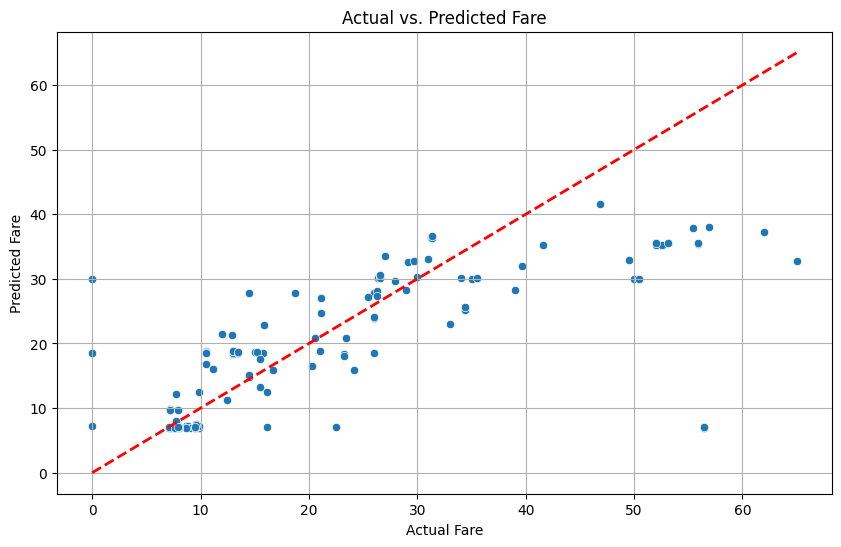

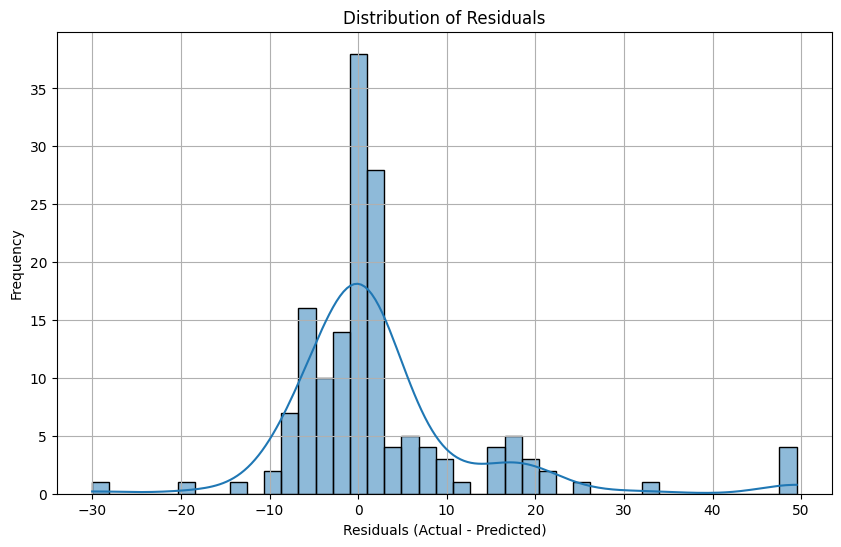

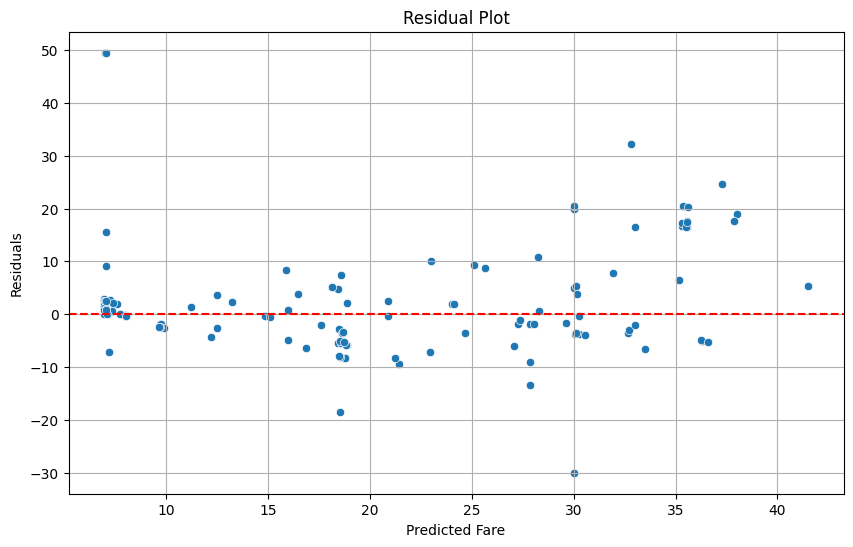

In [19]:
# Visualize Actual vs. Predicted values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual Fare")
plt.ylabel("Predicted Fare")
plt.title("Actual vs. Predicted Fare")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2) # Identity line
plt.grid(True)
plt.show()

# Visualize Residuals
residuals = y_test - y_pred
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True)
plt.xlabel("Residuals (Actual - Predicted)")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted Fare")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.grid(True)
plt.show()

In [20]:
# Calculate and print Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error (MAE): ${mae:.2f}")

Mean Absolute Error (MAE): $6.33
